# Loan Risk Descriptive & Predictive Analysis

This notebook uses a LendingClub accepted-loans sample data from https://www.kaggle.com/datasets/wordsforthewise/lending-club/code to predict whether a loan will be **Fully Paid** or **Charged Off**.

The target variable is `loan_status`:

- `0` = Fully Paid  
- `1` = Charged Off

This is an imbalanced binary classification problem because charged-off loans are the minority class. Therefore, the project prioritizes **precision, recall, F1-score, average precision, and threshold optimization** for the charged-off class rather than accuracy alone for model performance, making for a realistic and robust approach.

## Imports

In [156]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    brier_score_loss,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Data Loading with Selected Features

The cell below loads all the data from the sample dataset. I determined that from the 152 columns in the dataset, the following features were reasonable additions that did not contain potential data leakage.

In [157]:
# Local dataset path
path = "accepted_loans_sample_db.csv"

# Selected features used for loan default prediction
selected_features = [
    # Target
    "loan_status",

    # Loan characteristics
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose",

    # Borrower profile
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "dti",

    # Credit score and credit history
    "fico_range_low",
    "earliest_cr_line",
    "delinq_2yrs",
    "inq_last_6mths",
    "mths_since_last_delinq",
    "mths_since_last_record",

    # Account and balance information
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "acc_open_past_24mths",
    "bc_util",
]

# Check which selected features exist in the CSV
available_columns = pd.read_csv(path, nrows=0).columns.tolist()
features_available = [col for col in selected_features if col in available_columns]
features_missing = [col for col in selected_features if col not in available_columns]

print("Requested feature count:", len(selected_features))
print("Available selected features:", len(features_available))
print(features_available)
print("\nMissing selected features:")
print(features_missing)

# Load only available selected features
df_raw = pd.read_csv(path, usecols=features_available, low_memory=False)

print("\nOriginal dataset shape:", df_raw.shape)
df_raw.head()

Requested feature count: 27
Available selected features: 27
['loan_status', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'dti', 'fico_range_low', 'earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'acc_open_past_24mths', 'bc_util']

Missing selected features:
[]

Original dataset shape: (500000, 27)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,bc_util,mort_acc
0,7200.0,36 months,7.99,225.59,A,A4,9 years,MORTGAGE,202000.0,Source Verified,Charged Off,home_improvement,19.40,2.0,Jul-1990,680.0,0.0,15.0,NaN,21.0,0.0,224058.0,67.2,40.0,3.0,69.7,2.0
1,10000.0,36 months,7.90,312.91,A,A4,9 years,MORTGAGE,37617.0,Verified,Fully Paid,credit_card,20.61,0.0,Dec-1998,725.0,0.0,NaN,NaN,7.0,0.0,5404.0,70.2,12.0,2.0,75.0,3.0
2,35000.0,36 months,7.89,1095.00,A,A5,4 years,MORTGAGE,200000.0,Source Verified,Fully Paid,other,14.95,3.0,Mar-2002,680.0,0.0,4.0,NaN,12.0,0.0,19798.0,59.3,34.0,8.0,72.3,5.0
3,5000.0,36 months,16.29,176.51,D,D1,1 year,MORTGAGE,50000.0,Source Verified,Fully Paid,debt_consolidation,22.28,0.0,Sep-1995,670.0,1.0,75.0,NaN,5.0,0.0,16536.0,61.9,20.0,3.0,99.6,2.0
4,20000.0,36 months,18.25,725.56,E,E1,3 years,RENT,65000.0,Verified,Fully Paid,debt_consolidation,10.65,0.0,Dec-2007,660.0,3.0,NaN,NaN,8.0,0.0,10633.0,42.9,12.0,7.0,37.5,0.0


## 2. Initial Data Quality Check

In [158]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   loan_amnt               500000 non-null  float64
 1   term                    500000 non-null  str    
 2   int_rate                500000 non-null  float64
 3   installment             500000 non-null  float64
 4   grade                   500000 non-null  str    
 5   sub_grade               500000 non-null  str    
 6   emp_length              470699 non-null  str    
 7   home_ownership          500000 non-null  str    
 8   annual_inc              500000 non-null  float64
 9   verification_status     500000 non-null  str    
 10  loan_status             500000 non-null  str    
 11  purpose                 500000 non-null  str    
 12  dti                     499851 non-null  float64
 13  delinq_2yrs             500000 non-null  float64
 14  earliest_cr_line        500000 

In [159]:
missing_summary = (
    df_raw.isnull()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df_raw) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_pct
mths_since_last_record,415306,83.06
mths_since_last_delinq,252340,50.47
emp_length,29301,5.86
bc_util,23080,4.62
acc_open_past_24mths,17688,3.54
mort_acc,17688,3.54
revol_util,328,0.07
dti,149,0.03
inq_last_6mths,1,0.00
term,0,0.00


## Target Filtering and Encoding
This cell prepares the target variable and a few categorical features so they can be used in descriptive analysis and modeling. It turns loan outcomes, grades, and verification status into numeric values.

In [160]:
df = df_raw.copy()

# Keep only final repayment outcomes
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

print("Dataset shape after keeping final loan outcomes:", df.shape)
print(df["loan_status"].value_counts())

# Encode target variable
df["loan_status"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

# Encode loan grade: A is strongest and G is weakest
grade_map = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7,
}
df["grade"] = df["grade"].map(grade_map)

# Encode verification status: Source Verified and Verified are grouped as verified
verify_map = {
    "Not Verified": 0,
    "Source Verified": 1,
    "Verified": 1,
}
df["verification_status"] = df["verification_status"].map(verify_map)

df.head()

Dataset shape after keeping final loan outcomes: (500000, 27)
loan_status
Fully Paid     400187
Charged Off     99813
Name: count, dtype: int64


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,bc_util,mort_acc
0,7200.0,36 months,7.99,225.59,1,A4,9 years,MORTGAGE,202000.0,1,1,home_improvement,19.40,2.0,Jul-1990,680.0,0.0,15.0,NaN,21.0,0.0,224058.0,67.2,40.0,3.0,69.7,2.0
1,10000.0,36 months,7.90,312.91,1,A4,9 years,MORTGAGE,37617.0,1,0,credit_card,20.61,0.0,Dec-1998,725.0,0.0,NaN,NaN,7.0,0.0,5404.0,70.2,12.0,2.0,75.0,3.0
2,35000.0,36 months,7.89,1095.00,1,A5,4 years,MORTGAGE,200000.0,1,0,other,14.95,3.0,Mar-2002,680.0,0.0,4.0,NaN,12.0,0.0,19798.0,59.3,34.0,8.0,72.3,5.0
3,5000.0,36 months,16.29,176.51,4,D1,1 year,MORTGAGE,50000.0,1,0,debt_consolidation,22.28,0.0,Sep-1995,670.0,1.0,75.0,NaN,5.0,0.0,16536.0,61.9,20.0,3.0,99.6,2.0
4,20000.0,36 months,18.25,725.56,5,E1,3 years,RENT,65000.0,1,0,debt_consolidation,10.65,0.0,Dec-2007,660.0,3.0,NaN,NaN,8.0,0.0,10633.0,42.9,12.0,7.0,37.5,0.0


## Feature Cleaning
The cell below cleans several columns to make them usable for modeling. Loan term, employment length, and revolving utilization were converted from text into numeric values. A missingness flag was created for employment length because missing employment information may contain useful risk information. The earliest credit line date was converted into credit history length, which is easier for the model to interpret.

In [161]:
# Clean term column
if "term" in df.columns:
    df["term"] = (
        df["term"]
        .astype(str)
        .str.replace(" months", "", regex=False)
        .str.strip()
    )
    df["term"] = pd.to_numeric(df["term"], errors="coerce")

# Missing employment length may contain useful risk information.
# Create a missingness flag before converting and imputing.
if "emp_length" in df.columns:
    df["emp_length_missing"] = df["emp_length"].isnull().astype(int)
    df["emp_length"] = (
        df["emp_length"]
        .astype(str)
        .str.replace("10+ years", "10", regex=False)
        .str.replace("< 1 year", "0", regex=False)
        .str.replace(" years", "", regex=False)
        .str.replace(" year", "", regex=False)
        .str.replace("nan", "", regex=False)
        .str.strip()
    )
    df["emp_length"] = pd.to_numeric(df["emp_length"], errors="coerce")

# Clean revolving utilization.
# revol_util may appear as "45.6%" or as a numeric value.
if "revol_util" in df.columns:
    df["revol_util"] = (
        df["revol_util"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .replace("nan", np.nan)
    )
    df["revol_util"] = pd.to_numeric(df["revol_util"], errors="coerce")

    # If values are proportions like 0.456, convert them to percentages.
    if df["revol_util"].dropna().max() <= 1:
        df["revol_util"] = df["revol_util"] * 100

# Convert earliest credit line into credit history length.
# The dataset ends around 2018Q4, so 2018 is used as the reference year.
if "earliest_cr_line" in df.columns:
    earliest_dates = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
    df["credit_history_years"] = 2018 - earliest_dates.dt.year
    df = df.drop(columns=["earliest_cr_line"])

print("Feature cleaning completed.")
df.head()

Feature cleaning completed.


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,delinq_2yrs,fico_range_low,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,bc_util,mort_acc,emp_length_missing,credit_history_years
0,7200.0,36,7.99,225.59,1,A4,9.0,MORTGAGE,202000.0,1,1,home_improvement,19.40,2.0,680.0,0.0,15.0,NaN,21.0,0.0,224058.0,67.2,40.0,3.0,69.7,2.0,0,28
1,10000.0,36,7.90,312.91,1,A4,9.0,MORTGAGE,37617.0,1,0,credit_card,20.61,0.0,725.0,0.0,NaN,NaN,7.0,0.0,5404.0,70.2,12.0,2.0,75.0,3.0,0,20
2,35000.0,36,7.89,1095.00,1,A5,4.0,MORTGAGE,200000.0,1,0,other,14.95,3.0,680.0,0.0,4.0,NaN,12.0,0.0,19798.0,59.3,34.0,8.0,72.3,5.0,0,16
3,5000.0,36,16.29,176.51,4,D1,1.0,MORTGAGE,50000.0,1,0,debt_consolidation,22.28,0.0,670.0,1.0,75.0,NaN,5.0,0.0,16536.0,61.9,20.0,3.0,99.6,2.0,0,23
4,20000.0,36,18.25,725.56,5,E1,3.0,RENT,65000.0,1,0,debt_consolidation,10.65,0.0,660.0,3.0,NaN,NaN,8.0,0.0,10633.0,42.9,12.0,7.0,37.5,0.0,0,11


## Feature Engineering - Loan to Income
The cell below creates one engineered feature ```loan_to_income``` by dividing loan amount/ annual income to provide a simple risk indicator as higher loamns with lower incomes would logically increase risk.

In [162]:
# Safe denominators to avoid division by zero
annual_inc_safe=df["annual_inc"].replace(0,np.nan)
#main ratio feature
df["loan_to_income"]=df["loan_amnt"]/annual_inc_safe
df=df.replace([np.inf,-np.inf],np.nan)
print ( "Current shape:" , df . shape )

Current shape: (500000, 29)


## Descriptive Analysis

The cells below display a variety of charts used for a descriptive analysis on the features and provide insights on trends seen across the dataset.

In [163]:
status_counts = df["loan_status"].value_counts().sort_index()
status_pct = (status_counts / status_counts.sum() * 100).round(2)

status_summary = pd.DataFrame({
    "Loan Status": ["Fully Paid", "Charged Off"],
    "Count": status_counts.values,
    "Percentage": status_pct.values
})

status_summary

,Loan Status,Count,Percentage
0,Fully Paid,400187,80.04
1,Charged Off,99813,19.96


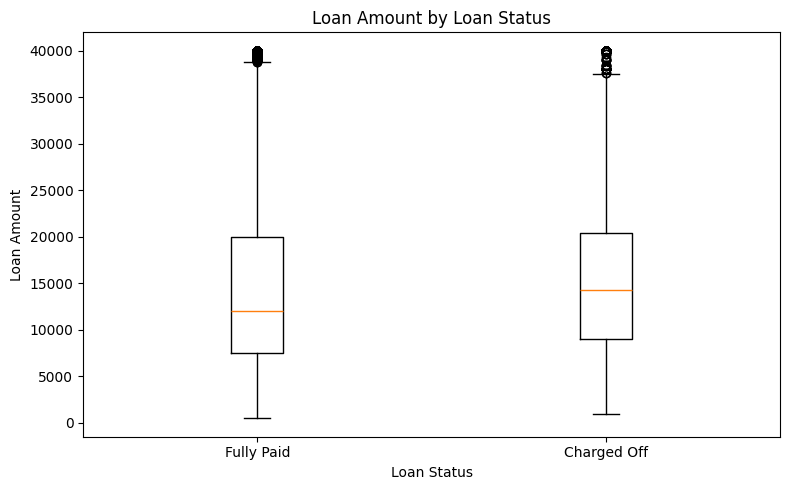

In [164]:
fully_paid_amnt = df[df["loan_status"] == 0]["loan_amnt"].dropna()
charged_off_amnt = df[df["loan_status"] == 1]["loan_amnt"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(
    [fully_paid_amnt, charged_off_amnt],
    labels=["Fully Paid", "Charged Off"]
)

plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()

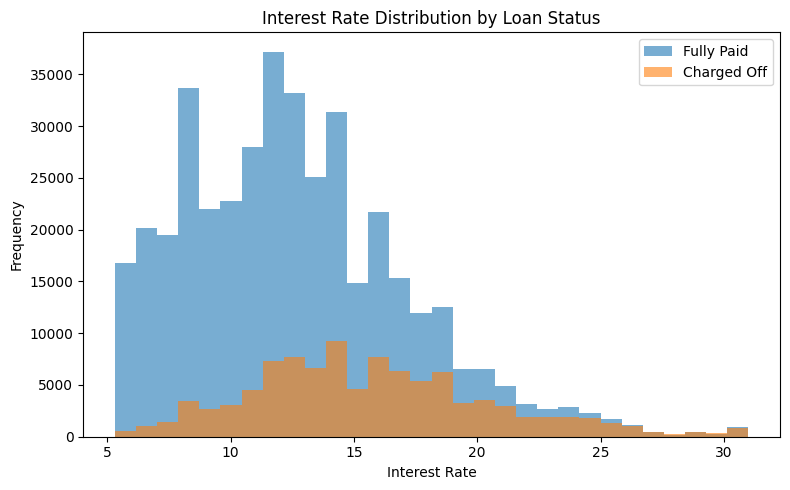

In [165]:
fully_paid_rates = df[df["loan_status"] == 0]["int_rate"]
charged_off_rates = df[df["loan_status"] == 1]["int_rate"]

plt.figure(figsize=(8, 5))
plt.hist(fully_paid_rates, bins=30, alpha=0.6, label="Fully Paid")
plt.hist(charged_off_rates, bins=30, alpha=0.6, label="Charged Off")
plt.title("Interest Rate Distribution by Loan Status")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

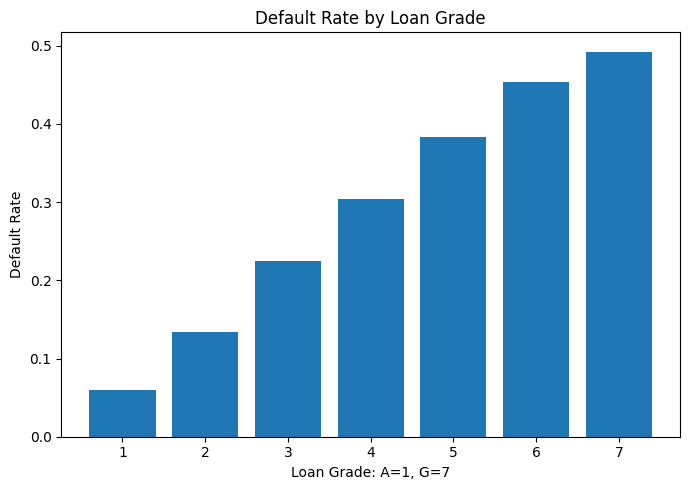

grade
1    0.060370
2    0.133923
3    0.224340
4    0.304332
5    0.383276
6    0.454285
7    0.492590
Name: loan_status, dtype: float64

In [166]:
grade_default_rate = df.groupby("grade")["loan_status"].mean()

plt.figure(figsize=(7, 5))
plt.bar(grade_default_rate.index.astype(str), grade_default_rate.values)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade: A=1, G=7")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

grade_default_rate

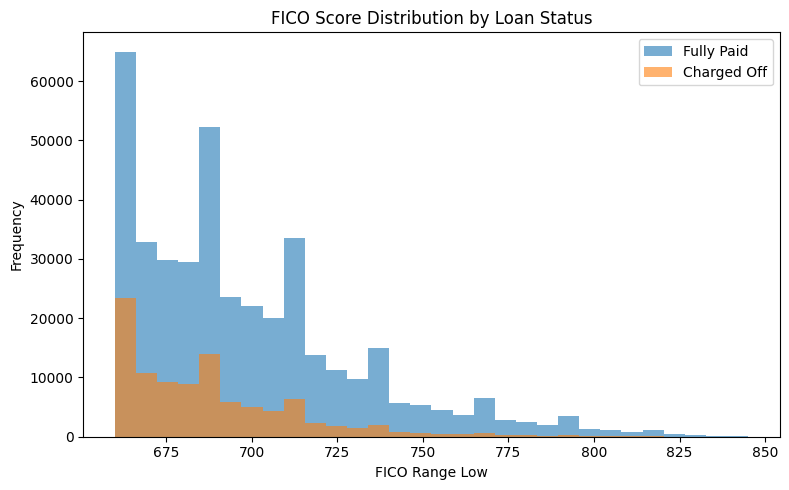

In [167]:
fully_paid_fico = df[df["loan_status"] == 0]["fico_range_low"]
charged_off_fico = df[df["loan_status"] == 1]["fico_range_low"]

plt.figure(figsize=(8, 5))
plt.hist(fully_paid_fico, bins=30, alpha=0.6, label="Fully Paid")
plt.hist(charged_off_fico, bins=30, alpha=0.6, label="Charged Off")
plt.title("FICO Score Distribution by Loan Status")
plt.xlabel("FICO Range Low")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

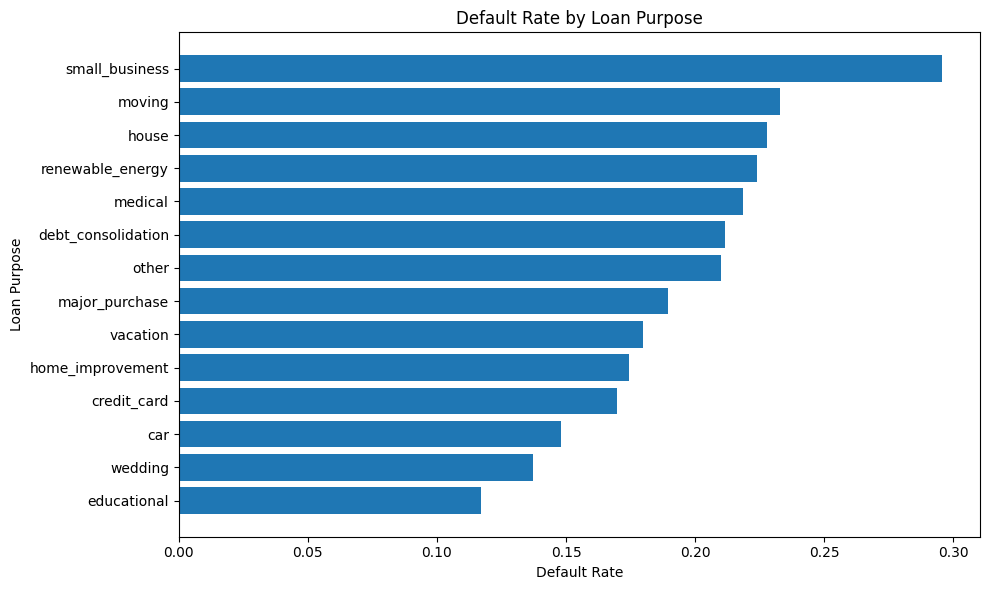

,Purpose,Default Rate
11,small_business,0.295518
8,moving,0.232974
5,house,0.227708
10,renewable_energy,0.224090
7,medical,0.218480
2,debt_consolidation,0.211688
9,other,0.209899
6,major_purchase,0.189436
12,vacation,0.179666
4,home_improvement,0.174394


In [168]:
purpose_default_df = (
    df.groupby("purpose")["loan_status"]
    .mean()
    .reset_index()
    .rename(columns={"purpose": "Purpose", "loan_status": "Default Rate"})
    .sort_values("Default Rate", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(purpose_default_df["Purpose"], purpose_default_df["Default Rate"])
plt.gca().invert_yaxis()
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate")
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()

purpose_default_df

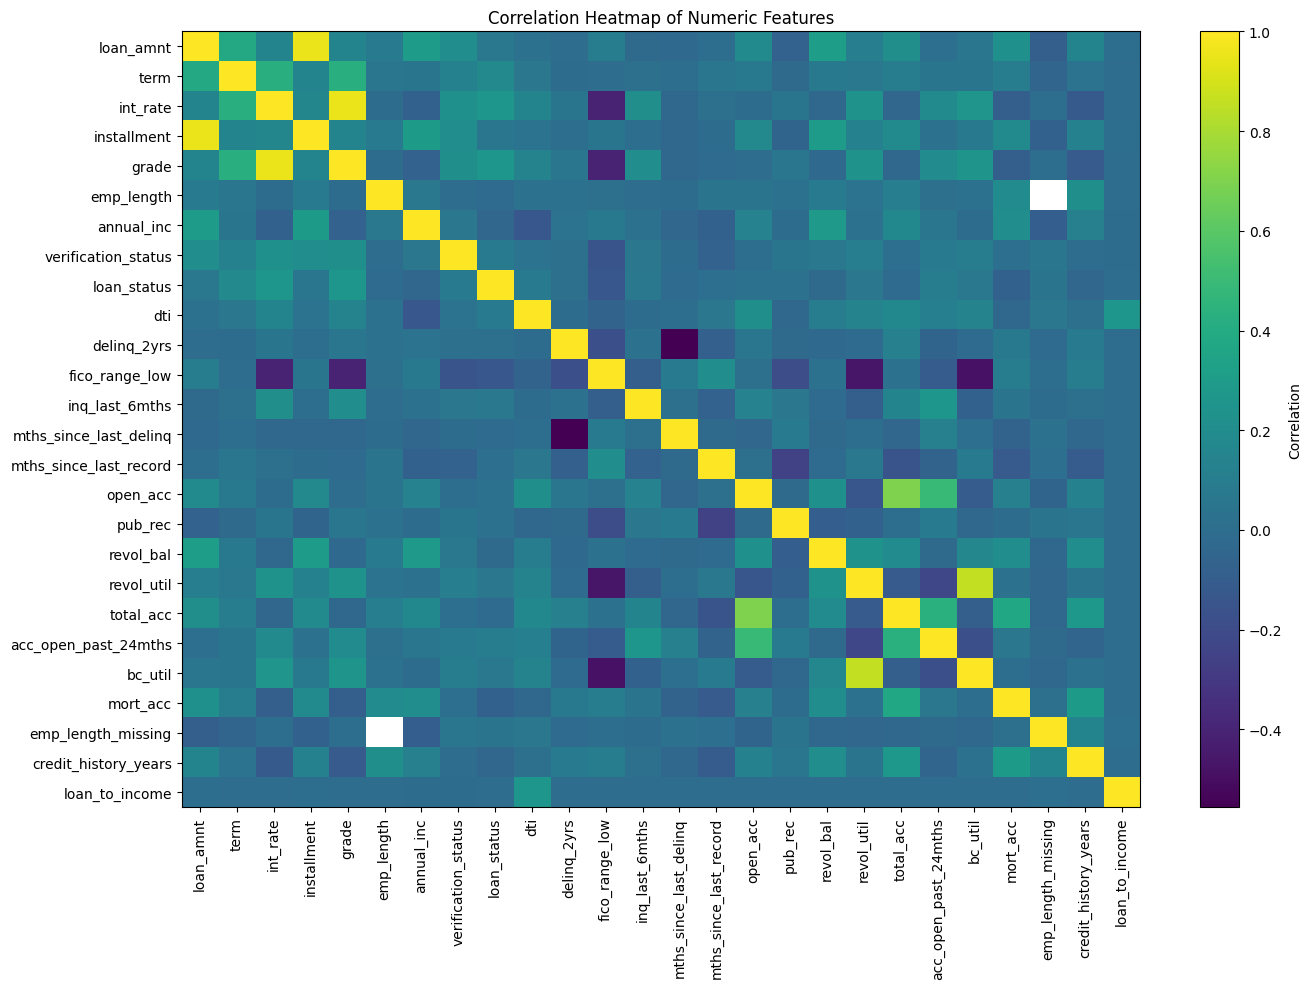

In [169]:
# Correlation heatmap for numeric features only

numeric_df = df.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(corr_matrix.index)),
    labels=corr_matrix.index
)

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

## Predictive Analysis - ML Model Design 

For the predictive analysis the following steps are taken:
- Splits the data into training and test sets.
- Cleans and prepares the features using the training data only.
- Tunes three models: Logistic Regression, XGBoost, and Random Forest.
- Uses 3-fold cross-validation during model tuning.
- Optimizes for F1-score because charged-off loans are the minority class.
- Calibrates XGBoost and Random Forest probabilities.
- Compares the models using precision, recall, F1-score, average precision, and Brier Score.
- Selects the best model and explain the results using a confusion matrix.

## Train/Test Split Before Train-Only Preprocessing
The cell below sets up training and testing data using an 80/20 split

In [170]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("\nTraining set:", X_train_raw.shape)
print("Test set:    ", X_test_raw.shape)

X shape: (500000, 28)
y shape: (500000,)

Target distribution (%):
loan_status
0    80.04
1    19.96
Name: proportion, dtype: float64

Training set: (400000, 28)
Test set:     (100000, 28)


## Train-Only Outlier Capping, Imputation, and Encoding
The cell below applies outlier capping using 1st and 99th percentile to stop outliers from skewing with model precision. The code also applies imputation to deal with missing values and one-hot encoding for categorical columns.

In [171]:
# Work on copies
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

# Outlier treatment columns
capping_columns = [
    "annual_inc",
    "revol_bal",
    "loan_amnt",
    "dti",
    "revol_util",
    "loan_to_income",
    "installment_to_monthly_income",
    "income_to_loan",
    "accounts_per_year",
    "rate_grade_gap",
]

# Fit capping thresholds on training data only, then apply to train and test
cap_thresholds = {}

for col in capping_columns:
    if col in X_train.columns:
        lower = X_train[col].quantile(0.01)
        upper = X_train[col].quantile(0.99)
        cap_thresholds[col] = (lower, upper)

        X_train[col] = X_train[col].clip(lower=lower, upper=upper)
        X_test[col] = X_test[col].clip(lower=lower, upper=upper)

print("Outlier capping completed using training-set percentiles only.")
pd.DataFrame(cap_thresholds, index=["lower_1pct", "upper_99pct"]).T

Outlier capping completed using training-set percentiles only.


,lower_1pct,upper_99pct
annual_inc,18000.000000,255000.00
revol_bal,164.000000,94988.08
loan_amnt,1550.000000,35000.00
dti,1.778000,38.44
revol_util,1.100000,98.30
loan_to_income,0.025316,0.50


In [172]:
# Drop redundant/modeling-risk columns after EDA but before modeling
cols_to_drop = ["grade", "installment_to_monthly_income", "int_rate"]
X_train = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])

print("Dropped redundant modeling columns:", cols_to_drop)
print("Train shape after drops:", X_train.shape)
print("Test shape after drops: ", X_test.shape)

Dropped redundant modeling columns: ['grade', 'installment_to_monthly_income', 'int_rate']
Train shape after drops: (400000, 26)
Test shape after drops:  (100000, 26)


In [173]:
# Identify columns after dropping redundant features
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", categorical_cols)

# Fit imputation values on training data only
numeric_medians = X_train[numeric_cols].median()
categorical_modes = X_train[categorical_cols].mode().iloc[0] if categorical_cols else pd.Series(dtype=object)

# Apply numeric imputation
X_train[numeric_cols] = X_train[numeric_cols].fillna(numeric_medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(numeric_medians)

# Apply categorical imputation
if categorical_cols:
    X_train[categorical_cols] = X_train[categorical_cols].fillna(categorical_modes)
    X_test[categorical_cols] = X_test[categorical_cols].fillna(categorical_modes)

print("Missing values after train-only imputation:")
print("Train:", X_train.isnull().sum().sum())
print("Test: ", X_test.isnull().sum().sum())

Numeric columns: 23
Categorical columns: ['sub_grade', 'home_ownership', 'purpose']
Missing values after train-only imputation:
Train: 0
Test:  0


In [174]:
# One-hot encode categorical variables.
# Fit categories on training data and align the test matrix to training columns.
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)

# Align columns so test set has exactly the same features in the same order
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Convert boolean dummy columns to integers
bool_cols_train = X_train.select_dtypes(include=["bool"]).columns
bool_cols_test = X_test.select_dtypes(include=["bool"]).columns

X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

print("Final modeling train shape:", X_train.shape)
print("Final modeling test shape: ", X_test.shape)
X_train.head()

Final modeling train shape: (400000, 78)
Final modeling test shape:  (100000, 78)


,loan_amnt,term,installment,emp_length,annual_inc,verification_status,dti,delinq_2yrs,fico_range_low,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,bc_util,mort_acc,emp_length_missing,credit_history_years,loan_to_income,sub_grade_A1,sub_grade_A2,sub_grade_A3,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,home_ownership_ANY,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
300475,12200.0,36,442.60,2.0,37000.0,1,7.30,0.0,685.0,0.0,31.0,72.0,8.0,0.0,5268.0,63.5,9.0,1.0,62.5,0.0,0,11,0.329730,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
470917,2500.0,36,86.24,6.0,50000.0,1,19.39,1.0,670.0,3.0,2.0,72.0,9.0,0.0,872.0,6.2,22.0,2.0,34.9,4.0,1,21,0.050000,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
43320,24000.0,36,772.17,10.0,80000.0,1,26.34,1.0,710.0,2.0,7.0,72.0,23.0,0.0,24142.0,29.4,38.0,11.0,38.4,3.0,0,20,0.300000,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
213768,30000.0,36,934.85,3.0,78000.0,1,12.06,0.0,810.0,1.0,31.0,72.0,8.0,0.0,2154.0,10.3,17.0,1.0,10.4,1.0,0,17,0.384615,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
29639,10650.0,36,384.28,10.0,52000.0,1,13.09,0.0,685.0,0.0,47.0,72.0,7.0,0.0,4157.0,47.2,10.0,6.0,45.0,2.0,0,14,0.204808,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


## Cross-Validation Strategy and Class Imbalance Handling
The cell below uses 3-fold stratified cross-validation to tune the models using F1-score for charged-off loans. Since charged-off loans are the minority class, class imbalance handling is used to give them more weight during training.

In [175]:
tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Optimize F1 for the charged-off class
f1_default_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)

negative_class = y_train.value_counts()[0]
positive_class = y_train.value_counts()[1]
scale_pos_weight = negative_class / positive_class

print("Negative class count:", negative_class)
print("Positive class count:", positive_class)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Negative class count: 320150
Positive class count: 79850
scale_pos_weight: 4.01


# Hyper Parameter Tunining
The following cells use parameter grid to for tuning paramters of selected models to ensure higher accuracy.

### Hyperparameter Tuning - XGBoost

In [176]:
xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_param_grid = {
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "scale_pos_weight": [
        scale_pos_weight * 0.75,
        scale_pos_weight,
        scale_pos_weight * 1.25,
    ],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring=f1_default_scorer,
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost CV F1:", round(xgb_search.best_score_, 4))
print("Best params:", xgb_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGBoost CV F1: 0.4291
Best params: {'subsample': 0.7, 'scale_pos_weight': np.float64(4.009392611145898), 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.7}


### Hyperparameter Tuning - Logistic Regression

In [177]:
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=2000,
        solver="liblinear",
    )),
])

log_reg_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
}

log_reg_search = RandomizedSearchCV(
    estimator=log_reg_pipeline,
    param_distributions=log_reg_param_grid,
    n_iter=10,
    scoring=f1_default_scorer,
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
)

log_reg_search.fit(X_train, y_train)

print("Best Logistic Regression CV F1:", round(log_reg_search.best_score_, 4))
print("Best params:", log_reg_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Logistic Regression CV F1: 0.4327
Best params: {'model__penalty': 'l2', 'model__C': 10}


### Hyperparameter Tuning - Random Forest

In [178]:
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring=f1_default_scorer,
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
)

rf_search.fit(X_train, y_train)

print("Best Random Forest CV F1:", round(rf_search.best_score_, 4))
print("Best params:", rf_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Random Forest CV F1: 0.4291
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 15}


## Probability Calibration

XGBoost and Random Forest often produce probabilities that are not well calibrated. Since this project uses threshold optimization, calibration helps make the predicted default probabilities more reliable, so the selected threshold is applied to probability scores that better reflect actual default risk.

In [179]:
xgb_calibrated = CalibratedClassifierCV(
    estimator=xgb_search.best_estimator_,
    method="isotonic",
    cv=3,
)
xgb_calibrated.fit(X_train, y_train)

rf_calibrated = CalibratedClassifierCV(
    estimator=rf_search.best_estimator_,
    method="isotonic",
    cv=3,
)
rf_calibrated.fit(X_train, y_train)

print("Calibration completed for XGBoost and Random Forest.")

Calibration completed for XGBoost and Random Forest.


## Model Comparison
The cell below provides performance metrics on the tested models, allowing for a comparison not just based off acuracy but recalls and precision as well.

In [180]:
models = {
    "Tuned XGBoost (calibrated)": xgb_calibrated,
    "Tuned Logistic Regression": log_reg_search.best_estimator_,
    "Tuned Random Forest (calibrated)": rf_calibrated,
}

threshold_grid = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for model_name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    for threshold in threshold_grid:
        y_pred_t = (y_proba >= threshold).astype(int)

        threshold_results.append({
            "Model": model_name,
            "Threshold": round(threshold, 2),
            "Accuracy": accuracy_score(y_test, y_pred_t),
            "Precision Defaults": precision_score(y_test, y_pred_t, pos_label=1, zero_division=0),
            "Recall Defaults": recall_score(y_test, y_pred_t, pos_label=1, zero_division=0),
            "F1 Defaults": f1_score(y_test, y_pred_t, pos_label=1, zero_division=0),
            "Average Precision": average_precision_score(y_test, y_proba),
            "Brier Score": brier_score_loss(y_test, y_proba),
        })

threshold_comparison_df = pd.DataFrame(threshold_results)

best_thresholds_df = (
    threshold_comparison_df
    .sort_values(["F1 Defaults", "Average Precision"], ascending=False)
    .groupby("Model", as_index=False)
    .first()
    .sort_values("F1 Defaults", ascending=False)
)

display_best_thresholds = best_thresholds_df.copy()

for col in [
    "Threshold",
    "Accuracy",
    "Precision Defaults",
    "Recall Defaults",
    "F1 Defaults",
    "Average Precision",
    "Brier Score",
]:
    display_best_thresholds[col] = display_best_thresholds[col].round(4)

display_best_thresholds

,Model,Threshold,Accuracy,Precision Defaults,Recall Defaults,F1 Defaults,Average Precision,Brier Score
0,Tuned Logistic Regression,0.54,0.6898,0.3423,0.6011,0.4362,0.3839,0.2150
2,Tuned XGBoost (calibrated),0.23,0.6871,0.3392,0.5981,0.4329,0.3824,0.1440
1,Tuned Random Forest (calibrated),0.21,0.6581,0.3235,0.6532,0.4327,0.3803,0.1442


In [181]:
best_row = best_thresholds_df.iloc[0]

best_model_name = best_row["Model"]
best_threshold = best_row["Threshold"]
best_model = models[best_model_name]

print("Best model after threshold optimization:", best_model_name)
print("Best threshold:", best_threshold)
print("Best F1 for defaults:", round(best_row["F1 Defaults"], 4))
print("Recall for defaults:", round(best_row["Recall Defaults"], 4))
print("Precision for defaults:", round(best_row["Precision Defaults"], 4))
print("Average precision:", round(best_row["Average Precision"], 4))

Best model after threshold optimization: Tuned Logistic Regression
Best threshold: 0.54
Best F1 for defaults: 0.4362
Recall for defaults: 0.6011
Precision for defaults: 0.3423
Average precision: 0.3839


## Confusion Matrix and Business Insight
The confusion matrix provides a business interpretation of how the model would perform in practice.

In [182]:
y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_proba_best >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Fully Paid", "Actual Charged Off"],
    columns=["Predicted Fully Paid", "Predicted Charged Off"],
)

cm_df

,Predicted Fully Paid,Predicted Charged Off
Actual Fully Paid,56986,23051
Actual Charged Off,7964,11999


## Conclusion

This project developed a complete loan default prediction workflow using real LendingClub accepted-loan data. Outliers were treated using percentile capping instead of row removal because extreme financial values may represent meaningful credit-risk behavior.

The predictive modeling section tested only three tuned models:

1. XGBoost  
2. Logistic Regression  
3. Random Forest  

The model preparation was based only on the training data, and the test set was kept untouched until final evaluation making for a more trustworthy evaluation. Because charged-off loans are the minority class, model evaluation focused on precision, recall, F1-score, average precision, and threshold optimization rather than accuracy alone.